#  Decision Tree Classifier

## Heart Disease Prediction using Decision Tree

Author: Varun Singh

### Objective

Build a Decision Tree Classifier to predict whether a patient has heart disease based on medical features.

## Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load Dataset

In [3]:
df = pd.read_csv("/heart-disease.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## Dataset Shape

In [4]:
df.shape

(303, 14)

## Column Names

In [5]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

## Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


## Statistical Summary

In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Missing Values

In [8]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


## Target Distribution

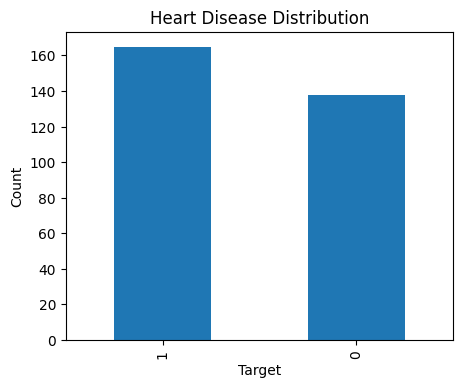

In [9]:
plt.figure(figsize=(5,4))

df["target"].value_counts().plot(kind="bar")

plt.title("Heart Disease Distribution")

plt.xlabel("Target")

plt.ylabel("Count")

plt.show()

## Correlation Heatmap

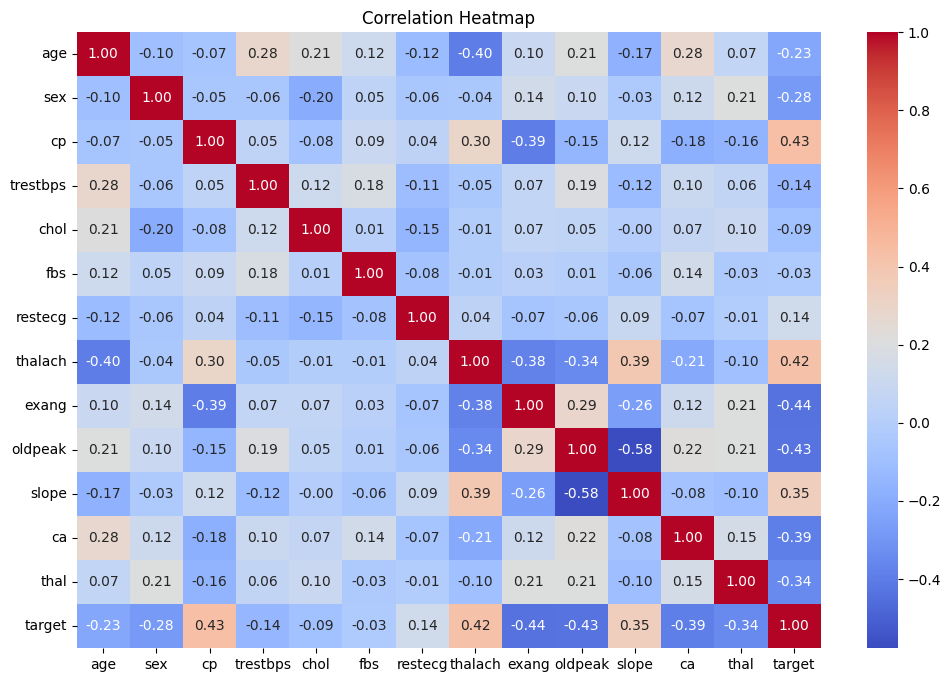

In [10]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

## Features (X) aur Target (y)

In [11]:
X = df.drop("target", axis=1)

y = df["target"]

## Check Features

In [12]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


## Check Target

In [13]:
y.head()

,target
0,1
1,1
2,1
3,1
4,1


## Train-Test Split

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Import Decision Tree

In [15]:
from sklearn.tree import DecisionTreeClassifier

## Create Decision Tree Model

In [16]:
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

## Train Model

In [17]:
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

## Prediction

In [18]:
y_pred = model.predict(X_test)

print(y_pred)

[0 1 0 0 1 0 1 0 0 1 1 1 1 0 1 1 1 0 0 0 1 0 1 1 1 0 1 1 0 1 0 0 0 0 1 0 0
 1 1 1 1 1 1 0 1 0 0 1 0 0 0 0 1 1 0 0 0 1 0 0 0]


## Compare Actual vs Predicted

In [19]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
179,0,0
228,0,1
111,1,0
246,0,0
60,1,1
9,1,0
119,1,1
223,0,0
268,0,0
33,1,1


## Check Training & Testing Accuracy

In [20]:
print("Training Accuracy :", model.score(X_train, y_train))

print("Testing Accuracy :", model.score(X_test, y_test))

Training Accuracy : 0.8842975206611571
Testing Accuracy : 0.8524590163934426


## Import Evaluation Metrics

In [21]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

## Accuracy Score

In [22]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score :", accuracy)

Accuracy Score : 0.8524590163934426


## Confusion Matrix

In [23]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[26  3]
 [ 6 26]]


## Confusion Matrix Visualization

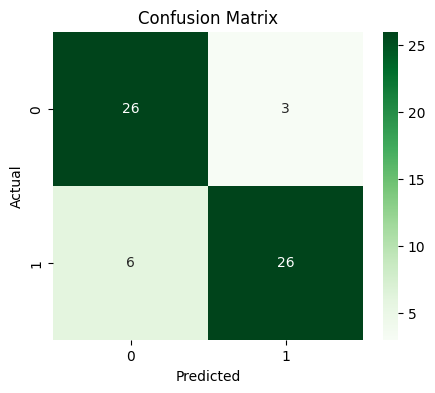

In [24]:
import seaborn as sns

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Classification Report

In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.90      0.85        29
           1       0.90      0.81      0.85        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.86      0.85      0.85        61



## Tree Visualization

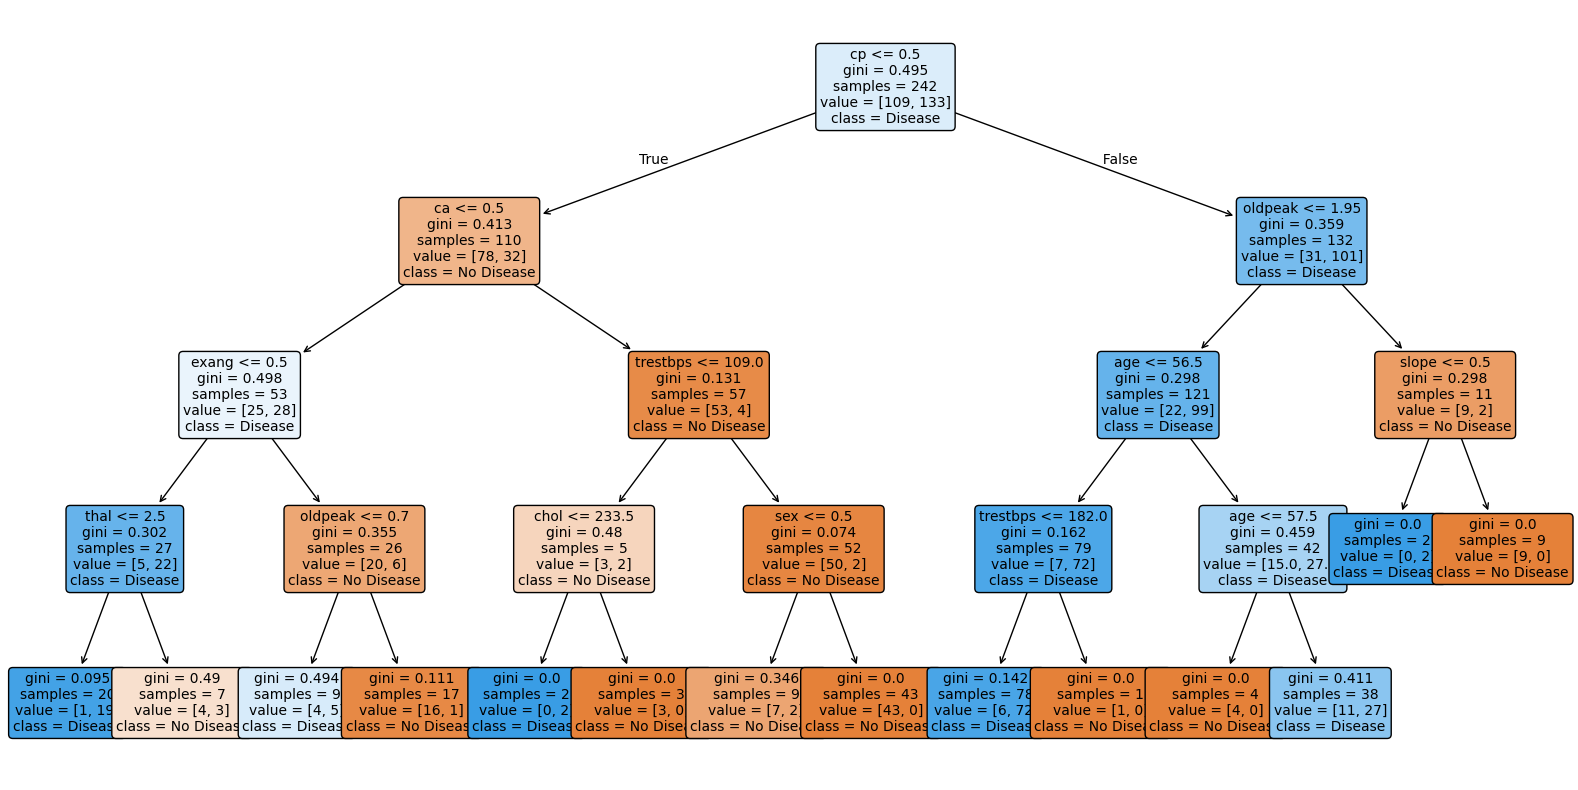

In [26]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.show()

## Feature Importance

In [27]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
2,cp,0.344530
11,ca,0.147165
9,oldpeak,0.141324
8,exang,0.115353
0,age,0.097133
10,slope,0.041779
3,trestbps,0.036702
12,thal,0.035994
4,chol,0.030638
1,sex,0.009383


## Feature Importance Graph

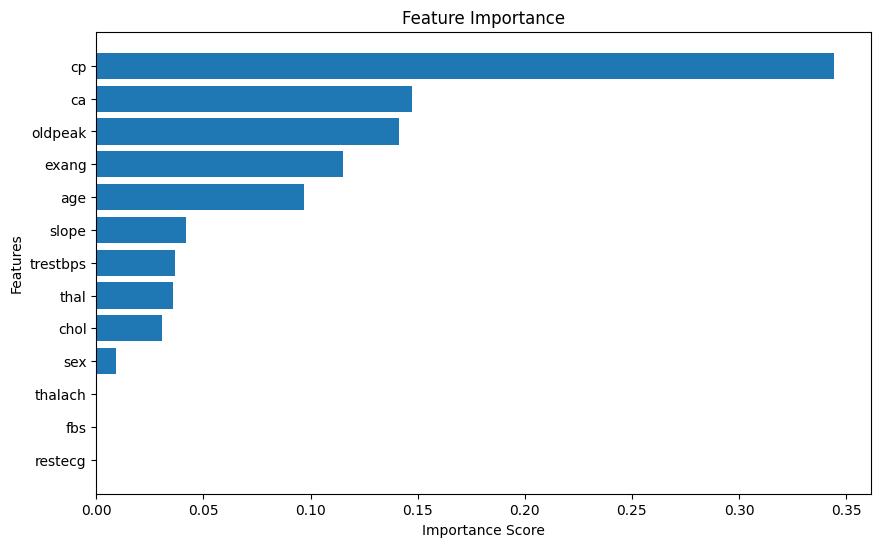

In [28]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

## Predict for a New Patient

In [29]:
new_patient = [[52,1,2,130,230,0,1,150,0,1.2,2,0,2]]

prediction = model.predict(new_patient)

if prediction[0] == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease")

Heart Disease Detected


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# ✅ Key Learnings

- Loaded the Heart Disease dataset
- Explored and analyzed the dataset
- Visualized target distribution and feature correlation
- Trained a Decision Tree Classifier
- Evaluated the model using Accuracy Score, Confusion Matrix, and Classification Report
- Visualized the Decision Tree
- Analyzed Feature Importance
- Predicted heart disease for a new patient